In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

import statsmodels.formula.api as smf
import statsmodels.api as sm
from pandas.api.types import is_numeric_dtype
import scipy.stats as ss

In [ ]:
PROJECT_ROOT = Path(r"G:/Final_proj/Total_clear/데이터")
DATA_DIR = PROJECT_ROOT / "data"
ANALYSIS_DIR = DATA_DIR / "analysis"
ERD_FIX_DIR = DATA_DIR / "ERD_final" / "final_fix"

products = pd.read_csv(ANALYSIS_DIR / "products_full.csv", encoding="utf-8-sig")
ingredients = pd.read_csv(ANALYSIS_DIR / "ingredients_full.csv", encoding="utf-8-sig")
promotions = pd.read_csv(ANALYSIS_DIR / "promotions_full.csv", encoding="utf-8-sig")
reviews = pd.read_csv(ANALYSIS_DIR / "reviews_full.csv", encoding="utf-8-sig")
user_id = pd.read_csv(ANALYSIS_DIR / "user_id_map.csv", encoding="utf-8-sig")
users = pd.read_csv(ANALYSIS_DIR / "users_full.csv", encoding="utf-8-sig")
absa = pd.read_csv(ERD_FIX_DIR / "review_absa.csv", encoding="utf-8-sig")
aspects = pd.read_csv(ERD_FIX_DIR / "review_aspects.csv", encoding="utf-8-sig")

print("공통 데이터 로드 완료")


In [237]:
df = products.copy()

In [238]:
# =================================================
# 1) Treatment 정의: 기능성 전체(1) vs 완전 비기능성(0)
# =================================================
flags = ['is_whitening','is_wrinkle_reduction','is_sunscreen','is_acne']

mask_non_func = df[flags].isna().all(axis=1)  # 완전 비기능성
mask_func = (
    (df['is_whitening'] == True) |
    (df['is_wrinkle_reduction'] == True) |
    (df['is_sunscreen'] == True) |
    (df['is_acne'] == True)
)

df["treatment"] = np.select(
    [mask_non_func, mask_func],
    [0, 1],
    default=np.nan
)

# 0/1만 사용
df = df[df["treatment"].isin([0,1])].copy()
df["treatment"] = df["treatment"].astype(int)

print("[treatment counts]\n", df["treatment"].value_counts())

[treatment counts]
 treatment
0    692
1    239
Name: count, dtype: int64


In [239]:
# =================================================
# 2) age_days 생성
# =================================================
df["first_review_date"] = pd.to_datetime(df.get("first_review_date"), errors="coerce")
crawl_date = pd.Timestamp("2026-02-26")

df["age_days"] = (crawl_date - df["first_review_date"]).dt.days
df["age_days"] = df["age_days"].clip(lower=0)
df["age_days_missing"] = df["first_review_date"].isna().astype(int)
df["age_days"] = df["age_days"].fillna(df["age_days"].median())

In [240]:
# =================================================
# 3) Outcome(리뷰집계) 붙이기 (가능한 것만)
# =================================================
if reviews is not None and {"product_code", "rating", "is_reorder"}.issubset(reviews.columns):
    rev_agg = (
        reviews.groupby("product_code")
        .agg(
            avg_rating=("rating", "mean"),
            reorder_rate=("is_reorder", "mean"),
            n_reviews=("rating", "size")
        )
        .reset_index()
    )
    df = df.merge(rev_agg, on="product_code", how="left")


# functional + category_2 + brand PSM, IPTW, OW

In [241]:
# =================================================
# 5) PS 모델 (공변량: price, age_days, category_1, category_2, brand_name)
# =================================================
cov_num = [c for c in ["price","age_days"] if c in df.columns]
cov_cat = [c for c in ["category_1"] if c in df.columns]

need_cols = cov_num + cov_cat + ["treatment"]
df_ps = df[need_cols].copy()

# 결측 최소 처리(모델 파이프라인에서 처리하지만, treatment 결측은 없어야 함)
df_ps = df_ps.dropna(subset=["treatment"]).copy()

X = df_ps[cov_num + cov_cat]
y = df_ps["treatment"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), cov_num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cov_cat),
    ],
    remainder="drop"
)

ps_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000))
])

ps_model.fit(X, y)
df_ps["ps"] = ps_model.predict_proba(X)[:, 1]

eps = 1e-6
ps_clip = np.clip(df_ps["ps"].values, eps, 1 - eps)
df_ps["ps_clip"] = ps_clip
df_ps["logit_ps"] = np.log(ps_clip / (1 - ps_clip))

print("[ps summary]\n", df_ps["ps"].describe())


[ps summary]
 count    931.000000
mean       0.256713
std        0.204826
min        0.014090
25%        0.073393
50%        0.200923
75%        0.461749
max        0.649527
Name: ps, dtype: float64


In [242]:
## ============== ps만 먼저 merge

df = df.merge(
    df_ps[["ps","ps_clip","logit_ps"]],
    left_index=True,
    right_index=True,
    how="inner"
)

In [243]:
p_t = df["treatment"].mean()
ps = df["ps_clip"].values

df["w_iptw_stab"] = np.where(
    df["treatment"]==1,
    p_t/ps,
    (1-p_t)/(1-ps)
)

df["w_ow"] = np.where(
    df["treatment"]==1,
    1-ps,
    ps
)

In [244]:
# =================================================
# 6) SMD 계산 (unweighted / weighted) - num + cat(onehot)
# =================================================
def _wmean(x, w):
    return np.sum(w * x) / np.sum(w)

def _wvar(x, w):
    mu = _wmean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd_numeric(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    m1 = _wmean(x[t==1], w[t==1])
    m0 = _wmean(x[t==0], w[t==0])
    v1 = _wvar(x[t==1], w[t==1])
    v0 = _wvar(x[t==0], w[t==0])
    pooled = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / pooled if pooled > 0 else 0.0

def smd_binary(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    p1 = _wmean(x[t==1], w[t==1])
    p0 = _wmean(x[t==0], w[t==0])
    pooled = np.sqrt((p1*(1-p1) + p0*(1-p0)) / 2)
    return (p1 - p0) / pooled if pooled > 0 else 0.0

def compute_smd_table(d, cov_num, cov_cat, treat_col="treatment", weight_col=None):
    t = d[treat_col].astype(int).values
    w = d[weight_col].values if weight_col else None
    rows = []

    for c in cov_num:
        if c not in d.columns:
            continue
        rows.append({"covariate": c, "type": "num",
                     "SMD": smd_numeric(d[c].astype(float).values, t, w)})

    for c in cov_cat:
        if c not in d.columns:
            continue
        dum = pd.get_dummies(d[c].astype("category"), prefix=c, drop_first=True)
        for col in dum.columns:
            rows.append({"covariate": col, "type": "cat",
                         "SMD": smd_binary(dum[col].values, t, w)})

    out = pd.DataFrame(rows)
    out["abs_SMD"] = out["SMD"].abs()
    out = out.sort_values("abs_SMD", ascending=False)
    return out

In [245]:
# =================================================
# 7) PSM (logit_ps NN + caliper)
# =================================================
def run_psm_match(df, caliper=0.2):

    d = df.copy()

    treated = d[d["treatment"]==1].copy()
    control = d[d["treatment"]==0].copy()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[["logit_ps"]])

    dist, idx = nn.kneighbors(treated[["logit_ps"]])

    treated["match_idx"] = idx.flatten()
    treated["distance"] = dist.flatten()

    sd_logit = d["logit_ps"].std()
    caliper_value = caliper * sd_logit

    matched_t = treated[treated["distance"] <= caliper_value].copy()
    matched_c = control.iloc[matched_t["match_idx"]].copy()

    matched_t["weight"] = 1.0
    matched_c["weight"] = 1.0

    matched = pd.concat([matched_t, matched_c], ignore_index=True)

    return matched

matched_sample = run_psm_match(df, caliper=0.2)

print("\n[PSM N]")
print("Original N:", len(df_ps),
      "T:", int((df_ps.treatment==1).sum()),
      "C:", int((df_ps.treatment==0).sum()))
print("Matched  N:", len(matched_sample),
      "T:", int((matched_sample.treatment==1).sum()),
      "C:", int((matched_sample.treatment==0).sum()))
print("Treated match success:",
      round(int((matched_sample.treatment==1).sum()) / max(int((df_ps.treatment==1).sum()),1) * 100, 2), "%")


[PSM N]
Original N: 931 T: 239 C: 692
Matched  N: 478 T: 239 C: 239
Treated match success: 100.0 %


In [246]:
# =================================================
# 8) IPTW / OW weights (df_ps 기준)
# =================================================
p_t = df_ps["treatment"].mean()
ps = df_ps["ps_clip"].values

df_ps["w_iptw_stab"] = np.where(df_ps["treatment"].values==1, p_t/ps, (1-p_t)/(1-ps))
df_ps["w_ow"] = np.where(df_ps["treatment"].values==1, 1-ps, ps)

print("\n[weights summary]")
print(df_ps[["w_iptw_stab","w_ow"]].describe())


[weights summary]
       w_iptw_stab        w_ow
count   931.000000  931.000000
mean      0.987208    0.299797
std       0.569159    0.247147
min       0.395231    0.014090
25%       0.783542    0.073501
50%       0.815463    0.219302
75%       1.006032    0.491469
max       5.347742    0.951996


In [247]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(df_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)  # PSM은 가중치 1
smd_iptw   = compute_smd_table(df_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(df_ps, cov_num, cov_cat, weight_col="w_ow")

print("\n[SMD check] share(|SMD|>0.1)")
for name, tab in [("Before", smd_before), ("PSM", smd_psm), ("IPTW", smd_iptw), ("OW", smd_ow)]:
    print(name, ":", round((tab["abs_SMD"] > 0.1).mean(), 4))

print("\nTop 15 |SMD| - Before")
print(smd_before.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After IPTW")
print(smd_iptw.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After OW")
print(smd_ow.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After PSM")
print(smd_psm.head(15)[["covariate","SMD","abs_SMD"]])


[SMD check] share(|SMD|>0.1)
Before : 1.0
PSM : 0.0
IPTW : 0.75
OW : 0.0

Top 15 |SMD| - Before
         covariate       SMD   abs_SMD
0            price  0.900543  0.900543
2  category_1_메이크업 -0.809895  0.809895
3  category_1_스킨케어  0.809428  0.809428
1         age_days -0.285519  0.285519

Top 15 |SMD| - After IPTW
         covariate       SMD   abs_SMD
3  category_1_스킨케어  0.213623  0.213623
2  category_1_메이크업 -0.179434  0.179434
1         age_days  0.121231  0.121231
0            price  0.028159  0.028159

Top 15 |SMD| - After OW
         covariate           SMD       abs_SMD
2  category_1_메이크업 -1.328533e-02  1.328533e-02
3  category_1_스킨케어  1.076567e-02  1.076567e-02
0            price -3.230574e-08  3.230574e-08
1         age_days  2.675922e-08  2.675922e-08

Top 15 |SMD| - After PSM
         covariate       SMD   abs_SMD
0            price -0.024330  0.024330
2  category_1_메이크업 -0.020575  0.020575
3  category_1_스킨케어  0.018631  0.018631
1         age_days -0.009167  0.009167


In [248]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(df_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)
smd_iptw   = compute_smd_table(df_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(df_ps, cov_num, cov_cat, weight_col="w_ow")

# 각 방법별 abs_SMD를 covariate 기준으로 합치기
smd_compare = (
    smd_before[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "Before"})
    .merge(smd_psm [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "PSM"}),   on="covariate")
    .merge(smd_iptw[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "IPTW"}),  on="covariate")
    .merge(smd_ow  [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "OW"}),    on="covariate")
    .sort_values("Before", ascending=False)
    .reset_index(drop=True)
)

# 평균 행 추가
mean_row = pd.DataFrame([{
    "covariate": "Mean |SMD|",
    "Before": smd_compare["Before"].mean(),
    "PSM":    smd_compare["PSM"].mean(),
    "IPTW":   smd_compare["IPTW"].mean(),
    "OW":     smd_compare["OW"].mean(),
}])
smd_compare = pd.concat([smd_compare, mean_row], ignore_index=True)

# 표 출력
method_order = ["Before", "PSM", "IPTW", "OW"]
float_cols = ["Before", "PSM", "IPTW", "OW"]
fmt = {c: "{:.4f}" for c in float_cols}

styled = (
    smd_compare.style
    .format(fmt)
    .highlight_between(subset=float_cols, left=0.1, right=999, color="#ffd6d6")   # |SMD|>0.1 빨강
    .highlight_between(subset=float_cols, left=0,   right=0.1, color="#d4edda")   # |SMD|≤0.1 초록
    .apply(lambda x: ["font-weight: bold"] * len(x)   # 마지막 행(Mean) 볼드
           if x.name == smd_compare.index[-1] else [""] * len(x), axis=1)
    .set_properties(**{"text-align": "right", "font-size": "13px", "padding": "6px 10px"})
    .set_table_styles([
        {"selector": "thead th", "props": [
            ("background-color", "#f0f0f0"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("border-bottom", "2px solid #ccc")
        ]},
    ])
    .set_caption("Absolute SMD by Method (red: |SMD|>0.1, green: balanced)")
)

styled

,covariate,Before,PSM,IPTW,OW
0,price,0.9005,0.0243,0.0282,0.0000
1,category_1_메이크업,0.8099,0.0206,0.1794,0.0133
2,category_1_스킨케어,0.8094,0.0186,0.2136,0.0108
3,age_days,0.2855,0.0092,0.1212,0.0000
4,Mean |SMD|,0.7013,0.0182,0.1356,0.0060


In [249]:
# =================================================
# 10) 효과추정: PSM / IPTW / OW (WLS, robust SE)
#     로그 변환: likes/shares/review_count/engagement_score만 log1p
# =================================================
LOG_OUTCOMES = {"likes","shares","review_count","engagement_score"}

def _prep_y(d, outcome):
    y = d[outcome].copy()
    log_flag = outcome in LOG_OUTCOMES
    if log_flag:
        y = np.log1p(y)
    return y, log_flag

def wls_treat_effect(d, outcome, weight_col=None):
    use = [outcome, "treatment"]
    if weight_col:
        use.append(weight_col)
    dd = d[use].dropna().copy()

    y, log_flag = _prep_y(dd, outcome)
    X = sm.add_constant(dd["treatment"].astype(int))
    if weight_col:
        m = sm.WLS(y, X, weights=dd[weight_col].astype(float)).fit(cov_type="HC1")
    else:
        m = sm.WLS(y, X, weights=np.ones(len(dd))).fit(cov_type="HC1")

    coef = m.params["treatment"]
    se = m.bse["treatment"]
    p = m.pvalues["treatment"]
    ci_low, ci_high = m.conf_int().loc["treatment"].tolist()

    out = {
        "outcome": outcome,
        "coef": float(coef),
        "Std.Err": float(se),
        "P-value": float(p),
        "CI_low": float(ci_low),
        "CI_high": float(ci_high),
        "n": int(len(dd)),
        "log1p": bool(log_flag),
    }
    if log_flag:
        out["Exp(Coef)"] = float(np.exp(coef))
    return out

outcomes = ["likes","shares","review_count","engagement_score","reorder_rate","avg_rating"]

rows = []

for yname in outcomes:

    if yname not in df.columns:
        continue

    # PSM
    rows.append({
        **wls_treat_effect(matched_sample, yname, weight_col=None),
        "method":"PSM"
    })

    # IPTW
    rows.append({
        **wls_treat_effect(df, yname, weight_col="w_iptw_stab"),
        "method":"IPTW(stab)"
    })

    # OW
    rows.append({
        **wls_treat_effect(df, yname, weight_col="w_ow"),
        "method":"OW"
    })

e_results = pd.DataFrame(rows)

print("\n[Effect estimates]")
print(e_results.sort_values(["outcome","method"]))


[Effect estimates]
             outcome      coef   Std.Err   P-value    CI_low   CI_high    n  \
16        avg_rating  0.002211  0.014204  0.876321 -0.025628  0.030049  920   
17        avg_rating -0.005759  0.010452  0.581648 -0.026244  0.014726  920   
15        avg_rating  0.000807  0.011079  0.941903 -0.020906  0.022521  474   
10  engagement_score  0.321890  0.134332  0.016565  0.058604  0.585177  931   
11  engagement_score  0.219481  0.100454  0.028896  0.022595  0.416366  931   
9   engagement_score  0.008204  0.113518  0.942384 -0.214287  0.230695  478   
1              likes  0.320993  0.146768  0.028737  0.033333  0.608652  931   
2              likes  0.209295  0.107770  0.052130 -0.001930  0.420520  931   
0              likes  0.016436  0.132386  0.901193 -0.243035  0.275908  478   
13      reorder_rate  0.034618  0.009717  0.000367  0.015573  0.053663  920   
14      reorder_rate  0.025524  0.009402  0.006635  0.007095  0.043952  920   
12      reorder_rate  0.019059  

In [250]:
def format_results(e_results) -> None:
    if not isinstance(e_results, pd.DataFrame):
        e_results = pd.DataFrame(e_results)
    
    col_order = ["method", "outcome", "coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)", "n", "log1p"]
    df_out = e_results[[c for c in col_order if c in list(e_results.columns)]].copy()
    
    method_order = ["PSM", "IPTW(stab)", "OW"]
    df_out["method"] = pd.Categorical(df_out["method"], categories=method_order, ordered=True)
    df_out = df_out.sort_values(["method", "outcome"]).reset_index(drop=True)
    
    float_cols = ["coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)"]
    fmt = {c: "{:.6f}" for c in float_cols if c in list(df_out.columns)}

    # P-value < 0.05 AND CI 0을 포함하지 않는 행 인덱스
    sig_mask = (
        (df_out["P-value"] < 0.05) &
        ~((df_out["CI_low"] <= 0) & (df_out["CI_high"] >= 0))  # 0을 포함하지 않음
    )

    def highlight_sig(row):
        if sig_mask.loc[row.name]:
            return ["background-color: #d4edda"] * len(row)
        return [""] * len(row)

    styled = (
        df_out.style
        .format(fmt)
        .apply(highlight_sig, axis=1)
        .set_properties(**{
            "text-align": "right",
            "font-size": "13px",
            "padding": "6px 12px"
        })
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color", "#f0f0f0"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "2px solid #ccc")
            ]},
            {"selector": "tbody tr:hover", "props": [
                ("background-color", "#f9f9f9")
            ]},
        ])
        .set_caption("Effect Estimates by Method & Outcome (green: p<0.05 & CI excludes 0)")
    )
    
    return styled

format_results(e_results)

,method,outcome,coef,Std.Err,P-value,CI_low,CI_high,Exp(Coef),n,log1p
0,PSM,avg_rating,0.000807,0.011079,0.941903,-0.020906,0.022521,nan,474,False
1,PSM,engagement_score,0.008204,0.113518,0.942384,-0.214287,0.230695,1.008238,478,True
2,PSM,likes,0.016436,0.132386,0.901193,-0.243035,0.275908,1.016572,478,True
3,PSM,reorder_rate,0.019059,0.009555,0.046081,0.000331,0.037786,nan,474,False
4,PSM,review_count,0.081019,0.121125,0.503567,-0.156382,0.318420,1.084392,478,True
5,PSM,shares,0.039037,0.110554,0.724012,-0.177646,0.255720,1.039809,478,True
6,IPTW(stab),avg_rating,0.002211,0.014204,0.876321,-0.025628,0.030049,nan,920,False
7,IPTW(stab),engagement_score,0.321890,0.134332,0.016565,0.058604,0.585177,1.379733,931,True
8,IPTW(stab),likes,0.320993,0.146768,0.028737,0.033333,0.608652,1.378495,931,True
9,IPTW(stab),reorder_rate,0.034618,0.009717,0.000367,0.015573,0.053663,nan,920,False


# 데이터 점검

           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          692.0  0.201670  0.182114  0.014090  0.066629  0.115782  0.255186   
1          239.0  0.416086  0.182566  0.048004  0.254986  0.464752  0.579526   

                max  
treatment            
0          0.649288  
1          0.649527  


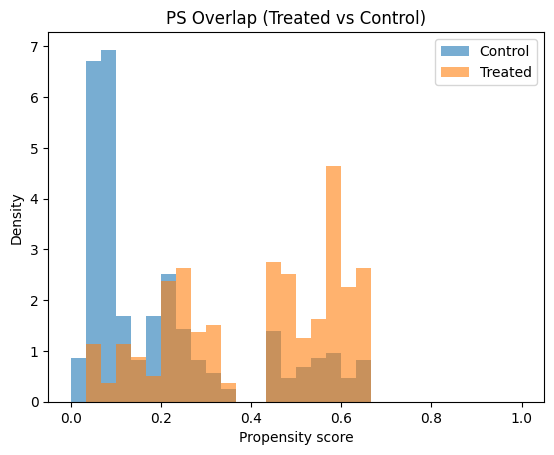

Common support interval: (np.float64(0.04800404076720992), np.float64(0.6492878014915812))
Outside common support share: 0.050483351235230935


In [251]:
# PS 클립(표시/계산 안정)
eps = 1e-6
df["ps_clip"] = np.clip(df["ps"], eps, 1 - eps)

# 요약표
print(df.groupby("treatment")["ps_clip"].describe())

# 히스토그램 (treated vs control)
bins = np.linspace(0, 1, 31)

plt.figure()
plt.hist(df.loc[df["treatment"]==0, "ps_clip"], bins=bins, alpha=0.6, label="Control", density=True)
plt.hist(df.loc[df["treatment"]==1, "ps_clip"], bins=bins, alpha=0.6, label="Treated", density=True)
plt.xlabel("Propensity score")
plt.ylabel("Density")
plt.legend()
plt.title("PS Overlap (Treated vs Control)")
plt.show()

# 겹침 구간(공통 지지, common support) 체크
c_min, c_max = df.loc[df.treatment==0, "ps_clip"].min(), df.loc[df.treatment==0, "ps_clip"].max()
t_min, t_max = df.loc[df.treatment==1, "ps_clip"].min(), df.loc[df.treatment==1, "ps_clip"].max()
overlap_min, overlap_max = max(c_min, t_min), min(c_max, t_max)
print("Common support interval:", (overlap_min, overlap_max))

# 공통지지 밖 비율
out_cs = ((df["ps_clip"] < overlap_min) | (df["ps_clip"] > overlap_max)).mean()
print("Outside common support share:", out_cs)

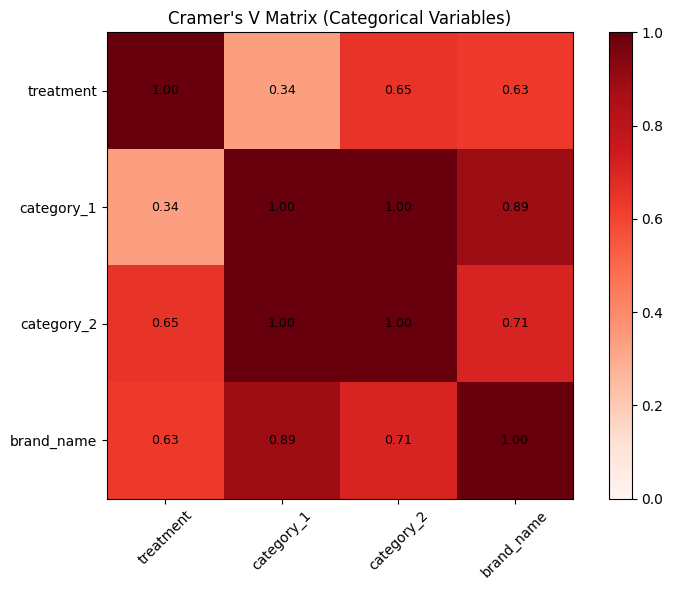

In [252]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# 포함할 범주형 변수들
cat_vars = ["treatment", "category_1", "category_2", "brand_name"]

# Cramér's V 행렬 계산
n = len(cat_vars)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matrix[i, j] = cramers_v(df[cat_vars[i]], df[cat_vars[j]])

# 시각화
plt.figure(figsize=(8,6))
im = plt.imshow(matrix, cmap="Reds", vmin=0, vmax=1)
plt.colorbar(im)

plt.xticks(range(n), cat_vars, rotation=45)
plt.yticks(range(n), cat_vars)

# 각 셀에 값 표시
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{matrix[i, j]:.2f}",
                 ha="center", va="center", fontsize=9)

plt.title("Cramer's V Matrix (Categorical Variables)")
plt.tight_layout()
plt.show()

# functional PSM, IPTW, OW

In [253]:
functional = products.copy()

In [254]:
# =================================================
# 1) Treatment 정의: 기능성 전체(1) vs 완전 비기능성(0)
# =================================================
flags = ['is_whitening','is_wrinkle_reduction','is_sunscreen','is_acne']

mask_non_func = functional[flags].isna().all(axis=1)  # 완전 비기능성
mask_func = (
    (functional['is_whitening'] == True) |
    (functional['is_wrinkle_reduction'] == True) |
    (functional['is_sunscreen'] == True) |
    (functional['is_acne'] == True)
)

functional["treatment"] = np.select(
    [mask_non_func, mask_func],
    [0, 1],
    default=np.nan
)

# 0/1만 사용
functional = functional[functional["treatment"].isin([0,1])].copy()
functional["treatment"] = functional["treatment"].astype(int)

print("[treatment counts]\n", functional["treatment"].value_counts())

[treatment counts]
 treatment
0    692
1    239
Name: count, dtype: int64


In [255]:
# =================================================
# 2) age_days 생성
# =================================================
functional["first_review_date"] = pd.to_datetime(functional.get("first_review_date"), errors="coerce")
crawl_date = pd.Timestamp("2026-02-26")

functional["age_days"] = (crawl_date - functional["first_review_date"]).dt.days
functional["age_days"] = functional["age_days"].clip(lower=0)
functional["age_days_missing"] = functional["first_review_date"].isna().astype(int)
functional["age_days"] = functional["age_days"].fillna(functional["age_days"].median())

In [256]:
# =================================================
# 3) Outcome(리뷰집계) 붙이기 (가능한 것만)
# =================================================
if reviews is not None and {"product_code", "rating", "is_reorder"}.issubset(reviews.columns):
    rev_agg = (
        reviews.groupby("product_code")
        .agg(
            avg_rating=("rating", "mean"),
            reorder_rate=("is_reorder", "mean"),
            n_reviews=("rating", "size")
        )
        .reset_index()
    )
    functional = functional.merge(rev_agg, on="product_code", how="left")


In [257]:
# =================================================
# 5) PS 모델 (공변량: price, age_days, category_1, category_2, brand_name)
# =================================================
cov_num = [c for c in ["price","age_days"] if c in functional.columns]
cov_cat = [c for c in ["category_1","category_2","brand_name"] if c in functional.columns]

need_cols = cov_num + cov_cat + ["treatment"]
functional_ps = functional[need_cols].copy()

# 결측 최소 처리(모델 파이프라인에서 처리하지만, treatment 결측은 없어야 함)
functional_ps = functional_ps.dropna(subset=["treatment"]).copy()

X = functional_ps[cov_num + cov_cat]
y = functional_ps["treatment"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), cov_num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cov_cat),
    ],
    remainder="drop"
)

ps_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000))
])

ps_model.fit(X, y)
functional_ps["ps"] = ps_model.predict_proba(X)[:, 1]

eps = 1e-6
ps_clip = np.clip(functional_ps["ps"].values, eps, 1 - eps)
functional_ps["ps_clip"] = ps_clip
functional_ps["logit_ps"] = np.log(ps_clip / (1 - ps_clip))

print("[ps summary]\n", functional_ps["ps"].describe())


[ps summary]
 count    931.000000
mean       0.256708
std        0.287037
min        0.002500
25%        0.011125
50%        0.084084
75%        0.481315
max        0.974815
Name: ps, dtype: float64


In [258]:
## ============== ps만 먼저 merge

functional = functional.merge(
    functional_ps[["ps","ps_clip","logit_ps"]],
    left_index=True,
    right_index=True,
    how="inner"
)

In [259]:
p_t = functional["treatment"].mean()
ps = functional["ps_clip"].values

functional["w_iptw_stab"] = np.where(
    functional["treatment"]==1,
    p_t/ps,
    (1-p_t)/(1-ps)
)

functional["w_ow"] = np.where(
    functional["treatment"]==1,
    1-ps,
    ps
)

In [260]:
# =================================================
# 6) SMD 계산 (unweighted / weighted) - num + cat(onehot)
# =================================================
def _wmean(x, w):
    return np.sum(w * x) / np.sum(w)

def _wvar(x, w):
    mu = _wmean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd_numeric(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    m1 = _wmean(x[t==1], w[t==1])
    m0 = _wmean(x[t==0], w[t==0])
    v1 = _wvar(x[t==1], w[t==1])
    v0 = _wvar(x[t==0], w[t==0])
    pooled = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / pooled if pooled > 0 else 0.0

def smd_binary(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    p1 = _wmean(x[t==1], w[t==1])
    p0 = _wmean(x[t==0], w[t==0])
    pooled = np.sqrt((p1*(1-p1) + p0*(1-p0)) / 2)
    return (p1 - p0) / pooled if pooled > 0 else 0.0

def compute_smd_table(d, cov_num, cov_cat, treat_col="treatment", weight_col=None):
    t = d[treat_col].astype(int).values
    w = d[weight_col].values if weight_col else None
    rows = []

    for c in cov_num:
        if c not in d.columns:
            continue
        rows.append({"covariate": c, "type": "num",
                     "SMD": smd_numeric(d[c].astype(float).values, t, w)})

    for c in cov_cat:
        if c not in d.columns:
            continue
        dum = pd.get_dummies(d[c].astype("category"), prefix=c, drop_first=True)
        for col in dum.columns:
            rows.append({"covariate": col, "type": "cat",
                         "SMD": smd_binary(dum[col].values, t, w)})

    out = pd.DataFrame(rows)
    out["abs_SMD"] = out["SMD"].abs()
    out = out.sort_values("abs_SMD", ascending=False)
    return out

In [261]:
# =================================================
# 7) PSM (logit_ps NN + caliper)
# =================================================
def run_psm_match(functional, caliper=0.2):

    d = functional.copy()

    treated = d[d["treatment"]==1].copy()
    control = d[d["treatment"]==0].copy()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[["logit_ps"]])

    dist, idx = nn.kneighbors(treated[["logit_ps"]])

    treated["match_idx"] = idx.flatten()
    treated["distance"] = dist.flatten()

    sd_logit = d["logit_ps"].std()
    caliper_value = caliper * sd_logit

    matched_t = treated[treated["distance"] <= caliper_value].copy()
    matched_c = control.iloc[matched_t["match_idx"]].copy()

    matched_t["weight"] = 1.0
    matched_c["weight"] = 1.0

    matched = pd.concat([matched_t, matched_c], ignore_index=True)

    return matched

matched_sample = run_psm_match(functional, caliper=0.2)

print("\n[PSM N]")
print("Original N:", len(functional_ps),
      "T:", int((functional_ps.treatment==1).sum()),
      "C:", int((functional_ps.treatment==0).sum()))
print("Matched  N:", len(matched_sample),
      "T:", int((matched_sample.treatment==1).sum()),
      "C:", int((matched_sample.treatment==0).sum()))
print("Treated match success:",
      round(int((matched_sample.treatment==1).sum()) / max(int((functional_ps.treatment==1).sum()),1) * 100, 2), "%")


[PSM N]
Original N: 931 T: 239 C: 692
Matched  N: 448 T: 224 C: 224
Treated match success: 93.72 %


In [262]:
# =================================================
# 8) IPTW / OW weights (df_ps 기준)
# =================================================
p_t = functional_ps["treatment"].mean()
ps = functional_ps["ps_clip"].values

functional_ps["w_iptw_stab"] = np.where(functional_ps["treatment"].values==1, p_t/ps, (1-p_t)/(1-ps))
functional_ps["w_ow"] = np.where(functional_ps["treatment"].values==1, 1-ps, ps)

print("\n[weights summary]")
print(functional_ps[["w_iptw_stab","w_ow"]].describe())


[weights summary]
       w_iptw_stab        w_ow
count   931.000000  931.000000
mean      0.838888    0.194121
std       0.551859    0.219048
min       0.263346    0.002500
25%       0.745546    0.011125
50%       0.752457    0.076935
75%       0.825981    0.349127
max       6.494783    0.960474


In [263]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(functional_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)  # PSM은 가중치 1
smd_iptw   = compute_smd_table(functional_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(functional_ps, cov_num, cov_cat, weight_col="w_ow")

print("\n[SMD check] share(|SMD|>0.1)")
for name, tab in [("Before", smd_before), ("PSM", smd_psm), ("IPTW", smd_iptw), ("OW", smd_ow)]:
    print(name, ":", round((tab["abs_SMD"] > 0.1).mean(), 4))

print("\nTop 15 |SMD| - Before")
print(smd_before.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After IPTW")
print(smd_iptw.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After OW")
print(smd_ow.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After PSM")
print(smd_psm.head(15)[["covariate","SMD","abs_SMD"]])


[SMD check] share(|SMD|>0.1)
Before : 0.5413
PSM : 0.411
IPTW : 0.4679
OW : 0.1835

Top 15 |SMD| - Before
              covariate       SMD   abs_SMD
0                 price  0.900543  0.900543
2       category_1_메이크업 -0.809895  0.809895
3       category_1_스킨케어  0.809428  0.809428
8      category_2_립메이크업 -0.686607  0.686607
11    category_2_아이메이크업 -0.670491  0.670491
12    category_2_자외선차단제  0.588713  0.588713
13  category_2_치크/하이라이터 -0.514917  0.514917
10   category_2_베이스메이크업  0.365348  0.365348
15    category_2_클렌징/필링 -0.350242  0.350242
45        brand_name_머지 -0.331295  0.331295
28       brand_name_다이소 -0.305949  0.305949
6     category_2_남성용면도기 -0.301056  0.301056
1              age_days -0.285519  0.285519
94      brand_name_트윙클팝 -0.284961  0.284961
91       brand_name_클리덤  0.282016  0.282016

Top 15 |SMD| - After IPTW
              covariate       SMD   abs_SMD
3       category_1_스킨케어  0.735133  0.735133
2       category_1_메이크업 -0.713017  0.713017
8      category_2_립메이크업 -0.604

In [264]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(functional_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)
smd_iptw   = compute_smd_table(functional_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(functional_ps, cov_num, cov_cat, weight_col="w_ow")

# 각 방법별 abs_SMD를 covariate 기준으로 합치기
smd_compare = (
    smd_before[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "Before"})
    .merge(smd_psm [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "PSM"}),   on="covariate")
    .merge(smd_iptw[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "IPTW"}),  on="covariate")
    .merge(smd_ow  [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "OW"}),    on="covariate")
    .sort_values("Before", ascending=False)
    .reset_index(drop=True)
)

# 평균 행 추가
mean_row = pd.DataFrame([{
    "covariate": "Mean |SMD|",
    "Before": smd_compare["Before"].mean(),
    "PSM":    smd_compare["PSM"].mean(),
    "IPTW":   smd_compare["IPTW"].mean(),
    "OW":     smd_compare["OW"].mean(),
}])
smd_compare = pd.concat([smd_compare, mean_row], ignore_index=True)

# 표 출력
method_order = ["Before", "PSM", "IPTW", "OW"]
float_cols = ["Before", "PSM", "IPTW", "OW"]
fmt = {c: "{:.4f}" for c in float_cols}

styled = (
    smd_compare.style
    .format(fmt)
    .highlight_between(subset=float_cols, left=0.1, right=999, color="#ffd6d6")   # |SMD|>0.1 빨강
    .highlight_between(subset=float_cols, left=0,   right=0.1, color="#d4edda")   # |SMD|≤0.1 초록
    .apply(lambda x: ["font-weight: bold"] * len(x)   # 마지막 행(Mean) 볼드
           if x.name == smd_compare.index[-1] else [""] * len(x), axis=1)
    .set_properties(**{"text-align": "right", "font-size": "13px", "padding": "6px 10px"})
    .set_table_styles([
        {"selector": "thead th", "props": [
            ("background-color", "#f0f0f0"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("border-bottom", "2px solid #ccc")
        ]},
    ])
    .set_caption("Absolute SMD by Method (red: |SMD|>0.1, green: balanced)")
)

styled

,covariate,Before,PSM,IPTW,OW
0,price,0.9005,0.1017,0.3351,0.0002
1,category_1_메이크업,0.8099,0.1547,0.7130,0.0318
2,category_1_스킨케어,0.8094,0.0961,0.7351,0.0203
3,category_2_자외선차단제,0.5887,0.2196,0.2869,0.1513
4,category_2_베이스메이크업,0.3653,0.1547,0.2213,0.0655
5,category_2_클렌징/필링,0.3502,0.2030,0.2933,0.0448
6,brand_name_다이소,0.3059,0.1907,0.2805,0.0220
7,category_2_남성용면도기,0.3011,0.0947,0.2737,0.1589
8,age_days,0.2855,0.2108,0.0257,0.0001
9,brand_name_클리덤,0.2820,0.3057,0.1825,0.1229


In [265]:
# =================================================
# 10) 효과추정: PSM / IPTW / OW (WLS, robust SE)
#     로그 변환: likes/shares/review_count/engagement_score만 log1p
# =================================================
LOG_OUTCOMES = {"likes","shares","review_count","engagement_score"}

def _prep_y(d, outcome):
    y = d[outcome].copy()
    log_flag = outcome in LOG_OUTCOMES
    if log_flag:
        y = np.log1p(y)
    return y, log_flag

def wls_treat_effect(d, outcome, weight_col=None):
    use = [outcome, "treatment"]
    if weight_col:
        use.append(weight_col)
    dd = d[use].dropna().copy()

    y, log_flag = _prep_y(dd, outcome)
    X = sm.add_constant(dd["treatment"].astype(int))
    if weight_col:
        m = sm.WLS(y, X, weights=dd[weight_col].astype(float)).fit(cov_type="HC1")
    else:
        m = sm.WLS(y, X, weights=np.ones(len(dd))).fit(cov_type="HC1")

    coef = m.params["treatment"]
    se = m.bse["treatment"]
    p = m.pvalues["treatment"]
    ci_low, ci_high = m.conf_int().loc["treatment"].tolist()

    out = {
        "outcome": outcome,
        "coef": float(coef),
        "Std.Err": float(se),
        "P-value": float(p),
        "CI_low": float(ci_low),
        "CI_high": float(ci_high),
        "n": int(len(dd)),
        "log1p": bool(log_flag),
    }
    if log_flag:
        out["Exp(Coef)"] = float(np.exp(coef))
    return out

outcomes = ["likes","shares","review_count","engagement_score","reorder_rate","avg_rating"]

rows = []

for yname in outcomes:

    if yname not in functional.columns:
        continue

    # PSM
    rows.append({
        **wls_treat_effect(matched_sample, yname, weight_col=None),
        "method":"PSM"
    })

    # IPTW
    rows.append({
        **wls_treat_effect(functional, yname, weight_col="w_iptw_stab"),
        "method":"IPTW(stab)"
    })

    # OW
    rows.append({
        **wls_treat_effect(functional, yname, weight_col="w_ow"),
        "method":"OW"
    })

e_results = pd.DataFrame(rows)

print("\n[Effect estimates]")
print(e_results.sort_values(["outcome","method"]))


[Effect estimates]
             outcome      coef   Std.Err   P-value    CI_low   CI_high    n  \
16        avg_rating  0.044485  0.011295  0.000082  0.022348  0.066622  920   
17        avg_rating -0.003736  0.011365  0.742325 -0.026011  0.018538  920   
15        avg_rating  0.018363  0.011968  0.124940 -0.005094  0.041820  446   
10  engagement_score  0.300248  0.117951  0.010911  0.069068  0.531428  931   
11  engagement_score  0.058145  0.115696  0.615266 -0.168614  0.284905  931   
9   engagement_score -0.110727  0.100903  0.272487 -0.308494  0.087040  448   
1              likes  0.310196  0.116518  0.007763  0.081826  0.538566  931   
2              likes  0.039518  0.117706  0.737074 -0.191182  0.270217  931   
0              likes -0.206376  0.110938  0.062847 -0.423811  0.011060  448   
13      reorder_rate  0.041715  0.012183  0.000617  0.017837  0.065592  920   
14      reorder_rate  0.014756  0.010616  0.164544 -0.006051  0.035563  920   
12      reorder_rate  0.035154  

In [266]:
def format_results(e_results) -> None:
    if not isinstance(e_results, pd.DataFrame):
        e_results = pd.DataFrame(e_results)
    
    col_order = ["method", "outcome", "coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)", "n", "log1p"]
    functional_out = e_results[[c for c in col_order if c in list(e_results.columns)]].copy()
    
    method_order = ["PSM", "IPTW(stab)", "OW"]
    functional_out["method"] = pd.Categorical(functional_out["method"], categories=method_order, ordered=True)
    functional_out = functional_out.sort_values(["method", "outcome"]).reset_index(drop=True)
    
    float_cols = ["coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)"]
    fmt = {c: "{:.6f}" for c in float_cols if c in list(functional_out.columns)}

    # P-value < 0.05 AND CI 0을 포함하지 않는 행 인덱스
    sig_mask = (
        (functional_out["P-value"] < 0.05) &
        ~((functional_out["CI_low"] <= 0) & (functional_out["CI_high"] >= 0))  # 0을 포함하지 않음
    )

    def highlight_sig(row):
        if sig_mask.loc[row.name]:
            return ["background-color: #d4edda"] * len(row)
        return [""] * len(row)

    styled = (
        functional_out.style
        .format(fmt)
        .apply(highlight_sig, axis=1)
        .set_properties(**{
            "text-align": "right",
            "font-size": "13px",
            "padding": "6px 12px"
        })
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color", "#f0f0f0"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "2px solid #ccc")
            ]},
            {"selector": "tbody tr:hover", "props": [
                ("background-color", "#f9f9f9")
            ]},
        ])
        .set_caption("Effect Estimates by Method & Outcome (green: p<0.05 & CI excludes 0)")
    )
    
    return styled

format_results(e_results)

,method,outcome,coef,Std.Err,P-value,CI_low,CI_high,Exp(Coef),n,log1p
0,PSM,avg_rating,0.018363,0.011968,0.124940,-0.005094,0.041820,nan,446,False
1,PSM,engagement_score,-0.110727,0.100903,0.272487,-0.308494,0.087040,0.895183,448,True
2,PSM,likes,-0.206376,0.110938,0.062847,-0.423811,0.011060,0.813527,448,True
3,PSM,reorder_rate,0.035154,0.009484,0.000210,0.016565,0.053743,nan,446,False
4,PSM,review_count,0.034378,0.113063,0.761079,-0.187221,0.255977,1.034976,448,True
5,PSM,shares,0.143666,0.108487,0.185416,-0.068966,0.356297,1.154498,448,True
6,IPTW(stab),avg_rating,0.044485,0.011295,0.000082,0.022348,0.066622,nan,920,False
7,IPTW(stab),engagement_score,0.300248,0.117951,0.010911,0.069068,0.531428,1.350193,931,True
8,IPTW(stab),likes,0.310196,0.116518,0.007763,0.081826,0.538566,1.363692,931,True
9,IPTW(stab),reorder_rate,0.041715,0.012183,0.000617,0.017837,0.065592,nan,920,False


# category_2 PSM, IPTW, OW

In [267]:
category = products.copy()

In [268]:
# =================================================
# 1) Treatment 정의: 기능성 전체(1) vs 완전 비기능성(0)
# =================================================
flags = ['is_whitening','is_wrinkle_reduction','is_sunscreen','is_acne']

mask_non_func = category[flags].isna().all(axis=1)  # 완전 비기능성
mask_func = (
    (category['is_whitening'] == True) |
    (category['is_wrinkle_reduction'] == True) |
    (category['is_sunscreen'] == True) |
    (category['is_acne'] == True)
)

category["treatment"] = np.select(
    [mask_non_func, mask_func],
    [0, 1],
    default=np.nan
)

# 0/1만 사용
category = category[category["treatment"].isin([0,1])].copy()
category["treatment"] = category["treatment"].astype(int)

print("[treatment counts]\n", category["treatment"].value_counts())

[treatment counts]
 treatment
0    692
1    239
Name: count, dtype: int64


In [269]:
# 카테고리2 별 총 제품 수 / 기능성 수
category_summary = (
    category.groupby("category_2")["treatment"]
      .agg(
          total_products="count",
          functional_products="sum"
      )
      .reset_index()
)

# 기능성 비율
category_summary["functional_ratio"] = (
    category_summary["functional_products"] /
    category_summary["total_products"]
)

category_summary.head()

,category_2,total_products,functional_products,functional_ratio
0,기초스킨케어,215,118,0.548837
1,남성메이크업,2,2,1.000000
2,남성스킨케어,26,15,0.576923
3,남성용면도기,30,0,0.000000
4,남성향수,6,0,0.000000


In [270]:
category_median_ratio = category_summary["functional_ratio"].median()
category_median_ratio

np.float64(0.06135902636916836)

In [271]:
category_summary["category_func_group"] = np.where(
    category_summary["functional_ratio"] >= category_median_ratio,
    1,   # 기능성 비중 높은 브랜드
    0    # 기능성 비중 낮은 브랜드
)

category_summary["category_func_group"].value_counts()

category_func_group
1    7
0    7
Name: count, dtype: int64

In [272]:
category = category.merge(
    category_summary[["category_2", "category_func_group"]],
    on="category_2",
    how="left"
)

category["category_func_group"].value_counts()

category_func_group
1    518
0    413
Name: count, dtype: int64

In [273]:
# =================================================
# 2) age_days 생성
# =================================================
category["first_review_date"] = pd.to_datetime(category.get("first_review_date"), errors="coerce")
crawl_date = pd.Timestamp("2026-02-26")

category["age_days"] = (crawl_date - category["first_review_date"]).dt.days
category["age_days"] = category["age_days"].clip(lower=0)
category["age_days_missing"] = category["first_review_date"].isna().astype(int)
category["age_days"] = category["age_days"].fillna(category["age_days"].median())

In [274]:
# =================================================
# 3) Outcome(리뷰집계) 붙이기 (가능한 것만)
# =================================================
if reviews is not None and {"product_code", "rating", "is_reorder"}.issubset(reviews.columns):
    rev_agg = (
        reviews.groupby("product_code")
        .agg(
            avg_rating=("rating", "mean"),
            reorder_rate=("is_reorder", "mean"),
            n_reviews=("rating", "size")
        )
        .reset_index()
    )
    category = category.merge(rev_agg, on="product_code", how="left")


In [275]:
# =================================================
# PS 모델 (공변량: price, age_days, brand_name, treatment)
#   → 종속변수: category_func_group
# =================================================

cov_num = [c for c in ["price","age_days"] if c in category.columns]
cov_cat = [c for c in ["brand_name","treatment"] if c in category.columns]

need_cols = cov_num + cov_cat + ["category_func_group"]
category_ps = category[need_cols].copy()

category_ps = category_ps.dropna(subset=["category_func_group"]).copy()

X = category_ps[cov_num + cov_cat]
y = category_ps["category_func_group"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), cov_num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cov_cat),
    ],
    remainder="drop"
)

ps_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000))
])

ps_model.fit(X, y)

category_ps["ps"] = ps_model.predict_proba(X)[:, 1]

eps = 1e-6
category_ps["ps_clip"] = np.clip(category_ps["ps"], eps, 1 - eps)
category_ps["logit_ps"] = np.log(category_ps["ps_clip"] / (1 - category_ps["ps_clip"]))

print("[category_func_group ps summary]\n", category_ps["ps"].describe())

[category_func_group ps summary]
 count    931.000000
mean       0.556360
std        0.352627
min        0.049917
25%        0.190863
50%        0.551816
75%        0.930422
max        0.998820
Name: ps, dtype: float64


In [276]:
## ============== ps만 먼저 merge

category = category.merge(
    category_ps[["ps","ps_clip","logit_ps"]],
    left_index=True,
    right_index=True,
    how="inner"
)

In [277]:
p_t = category["category_func_group"].mean()
ps = category["ps_clip"].values

category["w_iptw_stab"] = np.where(
    category["category_func_group"]==1,
    p_t/ps,
    (1-p_t)/(1-ps)
)

category["w_ow"] = np.where(
    category["category_func_group"]==1,
    1-ps,
    ps
)

In [278]:
# =================================================
# 6) SMD 계산 (unweighted / weighted) - num + cat(onehot)
# =================================================
def _wmean(x, w):
    return np.sum(w * x) / np.sum(w)

def _wvar(x, w):
    mu = _wmean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd_numeric(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    m1 = _wmean(x[t==1], w[t==1])
    m0 = _wmean(x[t==0], w[t==0])
    v1 = _wvar(x[t==1], w[t==1])
    v0 = _wvar(x[t==0], w[t==0])
    pooled = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / pooled if pooled > 0 else 0.0

def smd_binary(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    p1 = _wmean(x[t==1], w[t==1])
    p0 = _wmean(x[t==0], w[t==0])
    pooled = np.sqrt((p1*(1-p1) + p0*(1-p0)) / 2)
    return (p1 - p0) / pooled if pooled > 0 else 0.0

def compute_smd_table(d, cov_num, cov_cat, treat_col="category_func_group", weight_col=None):
    t = d[treat_col].astype(int).values
    w = d[weight_col].values if weight_col else None
    rows = []

    for c in cov_num:
        if c not in d.columns:
            continue
        rows.append({"covariate": c, "type": "num",
                     "SMD": smd_numeric(d[c].astype(float).values, t, w)})

    for c in cov_cat:
        if c not in d.columns:
            continue
        dum = pd.get_dummies(d[c].astype("category"), prefix=c, drop_first=True)
        for col in dum.columns:
            rows.append({"covariate": col, "type": "cat",
                         "SMD": smd_binary(dum[col].values, t, w)})

    out = pd.DataFrame(rows)
    out["abs_SMD"] = out["SMD"].abs()
    out = out.sort_values("abs_SMD", ascending=False)
    return out

In [279]:
# =================================================
# 7) PSM (logit_ps NN + caliper)
# =================================================
def run_psm_match(category, caliper=0.2):

    d = category.copy()

    treated = d[d["category_func_group"]==1].copy()
    control = d[d["category_func_group"]==0].copy()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[["logit_ps"]])

    dist, idx = nn.kneighbors(treated[["logit_ps"]])

    treated["match_idx"] = idx.flatten()
    treated["distance"] = dist.flatten()

    sd_logit = d["logit_ps"].std()
    caliper_value = caliper * sd_logit

    matched_t = treated[treated["distance"] <= caliper_value].copy()
    matched_c = control.iloc[matched_t["match_idx"]].copy()

    matched_t["weight"] = 1.0
    matched_c["weight"] = 1.0

    matched = pd.concat([matched_t, matched_c], ignore_index=True)

    return matched

matched_sample = run_psm_match(category, caliper=0.2)

print("\n[PSM N]")
print("Original N:", len(category_ps),
      "T:", int((category_ps.category_func_group==1).sum()),
      "C:", int((category_ps.category_func_group==0).sum()))
print("Matched  N:", len(matched_sample),
      "T:", int((matched_sample.category_func_group==1).sum()),
      "C:", int((matched_sample.category_func_group==0).sum()))
print("category_func_group match success:",
      round(int((matched_sample.category_func_group==1).sum()) / max(int((category_ps.category_func_group==1).sum()),1) * 100, 2), "%")


[PSM N]
Original N: 931 T: 518 C: 413
Matched  N: 442 T: 221 C: 221
category_func_group match success: 42.66 %


In [280]:
# =================================================
# 8) IPTW / OW weights (category_ps 기준)
# =================================================
p_t = category_ps["category_func_group"].mean()
ps = category_ps["ps_clip"].values

category_ps["w_iptw_stab"] = np.where(category_ps["category_func_group"].values==1, p_t/ps, (1-p_t)/(1-ps))
category_ps["w_ow"] = np.where(category_ps["category_func_group"].values==1, 1-ps, ps)

print("\n[weights summary]")
print(category_ps[["w_iptw_stab","w_ow"]].describe())


[weights summary]
       w_iptw_stab        w_ow
count   931.000000  931.000000
mean      0.718437    0.199025
std       0.516381    0.191944
min       0.466916    0.001180
25%       0.548249    0.052216
50%       0.576999    0.153627
75%       0.694804    0.275271
max      10.814804    0.958981


In [281]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(category_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)  # PSM은 가중치 1
smd_iptw   = compute_smd_table(category_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(category_ps, cov_num, cov_cat, weight_col="w_ow")

print("\n[SMD check] share(|SMD|>0.1)")
for name, tab in [("Before", smd_before), ("PSM", smd_psm), ("IPTW", smd_iptw), ("OW", smd_ow)]:
    print(name, ":", round((tab["abs_SMD"] > 0.1).mean(), 4))

print("\nTop 15 |SMD| - Before")
print(smd_before.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After IPTW")
print(smd_iptw.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After OW")
print(smd_ow.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After PSM")
print(smd_psm.head(15)[["covariate","SMD","abs_SMD"]])


[SMD check] share(|SMD|>0.1)
Before : 0.6737
PSM : 0.5065
IPTW : 0.6105
OW : 0.5789

Top 15 |SMD| - Before
                   covariate       SMD   abs_SMD
94               treatment_1  1.290708  1.290708
0                      price  0.781294  0.781294
30             brand_name_머지 -0.437014  0.437014
79           brand_name_트윙클팝 -0.374027  0.374027
50            brand_name_손앤박 -0.366561  0.366561
35       brand_name_밀크터치 디어씽 -0.327327  0.327327
90  brand_name_플레이101 by 에뛰드 -0.308542  0.308542
31            brand_name_메디필  0.290701  0.290701
19             brand_name_더봄 -0.254951  0.254951
41             brand_name_본셉 -0.251682  0.251682
72           brand_name_코시에로 -0.244643  0.244643
22            brand_name_도루코 -0.244643  0.244643
18           brand_name_더마블록  0.226903  0.226903
13            brand_name_다이소 -0.224024  0.224024
73           brand_name_코코가가 -0.222773  0.222773

Top 15 |SMD| - After IPTW
              covariate       SMD   abs_SMD
94          treatment_1  0.792725  0.

In [282]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(category_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)
smd_iptw   = compute_smd_table(category_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(category_ps, cov_num, cov_cat, weight_col="w_ow")

# 각 방법별 abs_SMD를 covariate 기준으로 합치기
smd_compare = (
    smd_before[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "Before"})
    .merge(smd_psm [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "PSM"}),   on="covariate")
    .merge(smd_iptw[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "IPTW"}),  on="covariate")
    .merge(smd_ow  [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "OW"}),    on="covariate")
    .sort_values("Before", ascending=False)
    .reset_index(drop=True)
)

# 평균 행 추가
mean_row = pd.DataFrame([{
    "covariate": "Mean |SMD|",
    "Before": smd_compare["Before"].mean(),
    "PSM":    smd_compare["PSM"].mean(),
    "IPTW":   smd_compare["IPTW"].mean(),
    "OW":     smd_compare["OW"].mean(),
}])
smd_compare = pd.concat([smd_compare, mean_row], ignore_index=True)

# 표 출력
method_order = ["Before", "PSM", "IPTW", "OW"]
float_cols = ["Before", "PSM", "IPTW", "OW"]
fmt = {c: "{:.4f}" for c in float_cols}

styled = (
    smd_compare.style
    .format(fmt)
    .highlight_between(subset=float_cols, left=0.1, right=999, color="#ffd6d6")   # |SMD|>0.1 빨강
    .highlight_between(subset=float_cols, left=0,   right=0.1, color="#d4edda")   # |SMD|≤0.1 초록
    .apply(lambda x: ["font-weight: bold"] * len(x)   # 마지막 행(Mean) 볼드
           if x.name == smd_compare.index[-1] else [""] * len(x), axis=1)
    .set_properties(**{"text-align": "right", "font-size": "13px", "padding": "6px 10px"})
    .set_table_styles([
        {"selector": "thead th", "props": [
            ("background-color", "#f0f0f0"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("border-bottom", "2px solid #ccc")
        ]},
    ])
    .set_caption("Absolute SMD by Method (red: |SMD|>0.1, green: balanced)")
)

styled

,covariate,Before,PSM,IPTW,OW
0,treatment_1,1.2907,0.0000,0.7927,0.1556
1,price,0.7813,0.3720,0.4580,0.0008
2,brand_name_플레이101 by 에뛰드,0.3085,0.0000,0.1480,0.1222
3,brand_name_메디필,0.2907,0.1659,0.2543,0.1967
4,brand_name_본셉,0.2517,0.2914,0.1123,0.0690
5,brand_name_더마블록,0.2269,0.1351,0.1970,0.1231
6,brand_name_다이소,0.2240,0.0490,0.0492,0.0250
7,brand_name_줌 바이 정샘물,0.2178,0.0953,0.1948,0.1690
8,brand_name_포인트,0.2178,0.1659,0.1962,0.1879
9,brand_name_비프루브,0.2178,0.1351,0.1895,0.1340


In [283]:
# =================================================
# 10) 효과추정: PSM / IPTW / OW (WLS, robust SE)
#     로그 변환: likes/shares/review_count/engagement_score만 log1p
# =================================================
LOG_OUTCOMES = {"likes","shares","review_count","engagement_score"}

def _prep_y(d, outcome):
    y = d[outcome].copy()
    log_flag = outcome in LOG_OUTCOMES
    if log_flag:
        y = np.log1p(y)
    return y, log_flag

def wls_cat_effect(d, outcome, weight_col=None):
    use = [outcome, "category_func_group"]
    if weight_col:
        use.append(weight_col)
    dd = d[use].dropna().copy()

    y, log_flag = _prep_y(dd, outcome)
    X = sm.add_constant(dd["category_func_group"].astype(int))
    if weight_col:
        m = sm.WLS(y, X, weights=dd[weight_col].astype(float)).fit(cov_type="HC1")
    else:
        m = sm.WLS(y, X, weights=np.ones(len(dd))).fit(cov_type="HC1")

    coef = m.params["category_func_group"]
    se = m.bse["category_func_group"]
    p = m.pvalues["category_func_group"]
    ci_low, ci_high = m.conf_int().loc["category_func_group"].tolist()

    out = {
        "outcome": outcome,
        "coef": float(coef),
        "Std.Err": float(se),
        "P-value": float(p),
        "CI_low": float(ci_low),
        "CI_high": float(ci_high),
        "n": int(len(dd)),
        "log1p": bool(log_flag),
    }
    if log_flag:
        out["Exp(Coef)"] = float(np.exp(coef))
    return out

outcomes = ["likes","shares","review_count","engagement_score","reorder_rate","avg_rating"]

rows = []

for yname in outcomes:

    if yname not in category.columns:
        continue

    # PSM
    rows.append({
        **wls_cat_effect(matched_sample, yname, weight_col=None),
        "method":"PSM"
    })

    # IPTW
    rows.append({
        **wls_cat_effect(category, yname, weight_col="w_iptw_stab"),
        "method":"IPTW(stab)"
    })

    # OW
    rows.append({
        **wls_cat_effect(category, yname, weight_col="w_ow"),
        "method":"OW"
    })

e_results = pd.DataFrame(rows)

print("\n[Effect estimates]")
print(e_results.sort_values(["outcome","method"]))


[Effect estimates]
             outcome      coef   Std.Err       P-value    CI_low   CI_high  \
16        avg_rating  0.075879  0.011130  9.281925e-12  0.054063  0.097694   
17        avg_rating  0.080732  0.012518  1.124098e-10  0.056197  0.105267   
15        avg_rating  0.072910  0.014970  1.113850e-06  0.043569  0.102251   
10  engagement_score  0.649637  0.104865  5.829380e-10  0.444105  0.855169   
11  engagement_score  0.715160  0.110170  8.502194e-11  0.499231  0.931089   
9   engagement_score  0.250675  0.114586  2.869540e-02  0.026089  0.475260   
1              likes  0.732885  0.110029  2.722732e-11  0.517232  0.948537   
2              likes  0.780224  0.126638  7.225054e-10  0.532019  1.028430   
0              likes  0.376234  0.148296  1.117919e-02  0.085579  0.666888   
13      reorder_rate  0.061345  0.010332  2.898944e-09  0.041094  0.081596   
14      reorder_rate  0.067585  0.009111  1.191102e-13  0.049727  0.085443   
12      reorder_rate  0.034501  0.009016  1.

In [284]:
def format_results(e_results) -> None:
    if not isinstance(e_results, pd.DataFrame):
        e_results = pd.DataFrame(e_results)
    
    col_order = ["method", "outcome", "coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)", "n", "log1p"]
    category_out = e_results[[c for c in col_order if c in list(e_results.columns)]].copy()
    
    method_order = ["PSM", "IPTW(stab)", "OW"]
    category_out["method"] = pd.Categorical(category_out["method"], categories=method_order, ordered=True)
    category_out = category_out.sort_values(["method", "outcome"]).reset_index(drop=True)
    
    float_cols = ["coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)"]
    fmt = {c: "{:.6f}" for c in float_cols if c in list(category_out.columns)}

    # P-value < 0.05 AND CI 0을 포함하지 않는 행 인덱스
    sig_mask = (
        (category_out["P-value"] < 0.05) &
        ~((category_out["CI_low"] <= 0) & (category_out["CI_high"] >= 0))  # 0을 포함하지 않음
    )

    def highlight_sig(row):
        if sig_mask.loc[row.name]:
            return ["background-color: #d4edda"] * len(row)
        return [""] * len(row)

    styled = (
        category_out.style
        .format(fmt)
        .apply(highlight_sig, axis=1)
        .set_properties(**{
            "text-align": "right",
            "font-size": "13px",
            "padding": "6px 12px"
        })
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color", "#f0f0f0"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "2px solid #ccc")
            ]},
            {"selector": "tbody tr:hover", "props": [
                ("background-color", "#f9f9f9")
            ]},
        ])
        .set_caption("Effect Estimates by Method & Outcome (green: p<0.05 & CI excludes 0)")
    )
    
    return styled

format_results(e_results)

,method,outcome,coef,Std.Err,P-value,CI_low,CI_high,Exp(Coef),n,log1p
0,PSM,avg_rating,0.072910,0.014970,0.000001,0.043569,0.102251,nan,420,False
1,PSM,engagement_score,0.250675,0.114586,0.028695,0.026089,0.475260,1.284892,442,True
2,PSM,likes,0.376234,0.148296,0.011179,0.085579,0.666888,1.456787,442,True
3,PSM,reorder_rate,0.034501,0.009016,0.000130,0.016831,0.052171,nan,420,False
4,PSM,review_count,0.484185,0.150322,0.001278,0.189559,0.778812,1.622852,442,True
5,PSM,shares,0.078602,0.111431,0.480569,-0.139799,0.297003,1.081774,442,True
6,IPTW(stab),avg_rating,0.075879,0.011130,0.000000,0.054063,0.097694,nan,920,False
7,IPTW(stab),engagement_score,0.649637,0.104865,0.000000,0.444105,0.855169,1.914846,931,True
8,IPTW(stab),likes,0.732885,0.110029,0.000000,0.517232,0.948537,2.081075,931,True
9,IPTW(stab),reorder_rate,0.061345,0.010332,0.000000,0.041094,0.081596,nan,920,False


# barand PSM, IPTW, OW

In [285]:
brand = products.copy()

In [286]:
# =================================================
# 1) Treatment 정의: 기능성 전체(1) vs 완전 비기능성(0)
# =================================================
flags = ['is_whitening','is_wrinkle_reduction','is_sunscreen','is_acne']

mask_non_func = brand[flags].isna().all(axis=1)  # 완전 비기능성
mask_func = (
    (brand['is_whitening'] == True) |
    (brand['is_wrinkle_reduction'] == True) |
    (brand['is_sunscreen'] == True) |
    (brand['is_acne'] == True)
)

brand["treatment"] = np.select(
    [mask_non_func, mask_func],
    [0, 1],
    default=np.nan
)

# 0/1만 사용
brand = brand[brand["treatment"].isin([0,1])].copy()
brand["treatment"] = brand["treatment"].astype(int)

print("[treatment counts]\n", brand["treatment"].value_counts())

[treatment counts]
 treatment
0    692
1    239
Name: count, dtype: int64


In [287]:
# 브랜드별 총 제품 수 / 기능성 수
brand_summary = (
    brand.groupby("brand_name")["treatment"]
      .agg(
          total_products="count",
          functional_products="sum"
      )
      .reset_index()
)

# 기능성 비율
brand_summary["functional_ratio"] = (
    brand_summary["functional_products"] /
    brand_summary["total_products"]
)

brand_summary.head()

,brand_name,total_products,functional_products,functional_ratio
0,AHC,7,7,1.000000
1,KAI,5,0,0.000000
2,LG생활건강,1,0,0.000000
3,VT,22,13,0.590909
4,과일나라,10,3,0.300000


In [288]:
median_ratio = brand_summary["functional_ratio"].median()
median_ratio

np.float64(0.1935483870967742)

In [289]:
brand_summary["brand_func_group"] = np.where(
    brand_summary["functional_ratio"] >= median_ratio,
    1,   # 기능성 비중 높은 브랜드
    0    # 기능성 비중 낮은 브랜드
)

brand_summary["brand_func_group"].value_counts()

brand_func_group
1    47
0    46
Name: count, dtype: int64

In [290]:
brand = brand.merge(
    brand_summary[["brand_name", "brand_func_group"]],
    on="brand_name",
    how="left"
)

brand["brand_func_group"].value_counts()

brand_func_group
0    494
1    437
Name: count, dtype: int64

In [291]:
# =================================================
# 2) age_days 생성
# =================================================
brand["first_review_date"] = pd.to_datetime(brand.get("first_review_date"), errors="coerce")
crawl_date = pd.Timestamp("2026-02-26")

brand["age_days"] = (crawl_date - brand["first_review_date"]).dt.days
brand["age_days"] = brand["age_days"].clip(lower=0)
brand["age_days_missing"] = brand["first_review_date"].isna().astype(int)
brand["age_days"] = brand["age_days"].fillna(brand["age_days"].median())

In [292]:
# =================================================
# 3) Outcome(리뷰집계) 붙이기 (가능한 것만)
# =================================================
if reviews is not None and {"product_code", "rating", "is_reorder"}.issubset(reviews.columns):
    rev_agg = (
        reviews.groupby("product_code")
        .agg(
            avg_rating=("rating", "mean"),
            reorder_rate=("is_reorder", "mean"),
            n_reviews=("rating", "size")
        )
        .reset_index()
    )
    brand = brand.merge(rev_agg, on="product_code", how="left")


In [293]:
# =================================================
# PS 모델 (공변량: price, age_days, brand_name, treatment)
#   → 종속변수: cat_skin
# =================================================

cov_num = [c for c in ["price","age_days"] if c in brand.columns]
cov_cat = [c for c in ["category_2","treatment"] if c in brand.columns]

need_cols = cov_num + cov_cat + ["brand_func_group"]
brand_ps = brand[need_cols].copy()

brand_ps = brand_ps.dropna(subset=["brand_func_group"]).copy()

X = brand_ps[cov_num + cov_cat]
y = brand_ps["brand_func_group"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), cov_num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cov_cat),
    ],
    remainder="drop"
)

ps_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000))
])

ps_model.fit(X, y)

brand_ps["ps"] = ps_model.predict_proba(X)[:, 1]

eps = 1e-6
brand_ps["ps_clip"] = np.clip(brand_ps["ps"], eps, 1 - eps)
brand_ps["logit_ps"] = np.log(brand_ps["ps_clip"] / (1 - brand_ps["ps_clip"]))

print("[brand_func_group ps summary]\n", brand_ps["ps"].describe())

[brand_func_group ps summary]
 count    931.000000
mean       0.469414
std        0.314906
min        0.015223
25%        0.178108
50%        0.382561
75%        0.804130
max        0.979091
Name: ps, dtype: float64


In [294]:
## ============== ps만 먼저 merge

brand = brand.merge(
    brand_ps[["ps","ps_clip","logit_ps"]],
    left_index=True,
    right_index=True,
    how="inner"
)

In [295]:
p_t = brand["brand_func_group"].mean()
ps = brand["ps_clip"].values

brand["w_iptw_stab"] = np.where(
    brand["brand_func_group"]==1,
    p_t/ps,
    (1-p_t)/(1-ps)
)

brand["w_ow"] = np.where(
    brand["brand_func_group"]==1,
    1-ps,
    ps
)

In [296]:
# =================================================
# 6) SMD 계산 (unweighted / weighted) - num + cat(onehot)
# =================================================
def _wmean(x, w):
    return np.sum(w * x) / np.sum(w)

def _wvar(x, w):
    mu = _wmean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd_numeric(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    m1 = _wmean(x[t==1], w[t==1])
    m0 = _wmean(x[t==0], w[t==0])
    v1 = _wvar(x[t==1], w[t==1])
    v0 = _wvar(x[t==0], w[t==0])
    pooled = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / pooled if pooled > 0 else 0.0

def smd_binary(x, t, w=None):
    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=int)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)

    p1 = _wmean(x[t==1], w[t==1])
    p0 = _wmean(x[t==0], w[t==0])
    pooled = np.sqrt((p1*(1-p1) + p0*(1-p0)) / 2)
    return (p1 - p0) / pooled if pooled > 0 else 0.0

def compute_smd_table(d, cov_num, cov_cat, treat_col="brand_func_group", weight_col=None):
    t = d[treat_col].astype(int).values
    w = d[weight_col].values if weight_col else None
    rows = []

    for c in cov_num:
        if c not in d.columns:
            continue
        rows.append({"covariate": c, "type": "num",
                     "SMD": smd_numeric(d[c].astype(float).values, t, w)})

    for c in cov_cat:
        if c not in d.columns:
            continue
        dum = pd.get_dummies(d[c].astype("category"), prefix=c, drop_first=True)
        for col in dum.columns:
            rows.append({"covariate": col, "type": "cat",
                         "SMD": smd_binary(dum[col].values, t, w)})

    out = pd.DataFrame(rows)
    out["abs_SMD"] = out["SMD"].abs()
    out = out.sort_values("abs_SMD", ascending=False)
    return out

In [297]:
# =================================================
# 7) PSM (logit_ps NN + caliper)
# =================================================
def run_psm_match(brand, caliper=0.2):

    d = brand.copy()

    treated = d[d["brand_func_group"]==1].copy()
    control = d[d["brand_func_group"]==0].copy()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[["logit_ps"]])

    dist, idx = nn.kneighbors(treated[["logit_ps"]])

    treated["match_idx"] = idx.flatten()
    treated["distance"] = dist.flatten()

    sd_logit = d["logit_ps"].std()
    caliper_value = caliper * sd_logit

    matched_t = treated[treated["distance"] <= caliper_value].copy()
    matched_c = control.iloc[matched_t["match_idx"]].copy()

    matched_t["weight"] = 1.0
    matched_c["weight"] = 1.0

    matched = pd.concat([matched_t, matched_c], ignore_index=True)

    return matched

matched_sample = run_psm_match(brand, caliper=0.2)

print("\n[PSM N]")
print("Original N:", len(brand),
      "T:", int((brand.brand_func_group==1).sum()),
      "C:", int((brand.brand_func_group==0).sum()))
print("Matched  N:", len(matched_sample),
      "T:", int((matched_sample.brand_func_group==1).sum()),
      "C:", int((matched_sample.brand_func_group==0).sum()))
print("brand_func_group match success:",
      round(int((matched_sample.brand_func_group==1).sum()) / max(int((brand.brand_func_group==1).sum()),1) * 100, 2), "%")


[PSM N]
Original N: 931 T: 437 C: 494
Matched  N: 814 T: 407 C: 407
brand_func_group match success: 93.14 %


In [298]:
# =================================================
# 8) IPTW / OW weights (brand 기준)
# =================================================
p_t = brand_ps["brand_func_group"].mean()
ps = brand_ps["ps_clip"].values

brand_ps["w_iptw_stab"] = np.where(brand_ps["brand_func_group"].values==1, p_t/ps, (1-p_t)/(1-ps))
brand_ps["w_ow"] = np.where(brand_ps["brand_func_group"].values==1, 1-ps, ps)

print("\n[weights summary]")
print(brand_ps[["w_iptw_stab","w_ow"]].describe())


[weights summary]
       w_iptw_stab        w_ow
count   931.000000  931.000000
mean      0.955659    0.295947
std       0.942161    0.241702
min       0.479412    0.015223
25%       0.570861    0.103692
50%       0.646068    0.220526
75%       0.879571    0.433190
max       9.247244    0.942619


In [299]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(brand_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)  # PSM은 가중치 1
smd_iptw   = compute_smd_table(brand_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(brand_ps, cov_num, cov_cat, weight_col="w_ow")

print("\n[SMD check] share(|SMD|>0.1)")
for name, tab in [("Before", smd_before), ("PSM", smd_psm), ("IPTW", smd_iptw), ("OW", smd_ow)]:
    print(name, ":", round((tab["abs_SMD"] > 0.1).mean(), 4))

print("\nTop 15 |SMD| - Before")
print(smd_before.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After IPTW")
print(smd_iptw.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After OW")
print(smd_ow.head(15)[["covariate","SMD","abs_SMD"]])

print("\nTop 15 |SMD| - After PSM")
print(smd_psm.head(15)[["covariate","SMD","abs_SMD"]])


[SMD check] share(|SMD|>0.1)
Before : 0.75
PSM : 0.4667
IPTW : 0.25
OW : 0.125

Top 15 |SMD| - Before
              covariate       SMD   abs_SMD
15          treatment_1  1.137651  1.137651
0                 price  0.942462  0.942462
6      category_2_립메이크업 -0.518534  0.518534
9     category_2_아이메이크업 -0.494519  0.494519
1              age_days -0.445437  0.445437
4     category_2_남성용면도기 -0.359597  0.359597
10    category_2_자외선차단제  0.349249  0.349249
8    category_2_베이스메이크업  0.303741  0.303741
3     category_2_남성스킨케어  0.278496  0.278496
11  category_2_치크/하이라이터 -0.217918  0.217918
5       category_2_남성향수 -0.156813  0.156813
13    category_2_클렌징/필링 -0.151496  0.151496
2     category_2_남성메이크업  0.095893  0.095893
7        category_2_립케어 -0.090438  0.090438
14     category_2_팩/마스크  0.071756  0.071756

Top 15 |SMD| - After IPTW
             covariate       SMD   abs_SMD
4    category_2_남성용면도기 -0.272825  0.272825
6     category_2_립메이크업 -0.143086  0.143086
5      category_2_남성향수 -0.123523  0.1

In [300]:
# =================================================
# 9) SMD: 전/후(PSM, IPTW, OW)
# =================================================
smd_before = compute_smd_table(brand_ps, cov_num, cov_cat, weight_col=None)
smd_psm    = compute_smd_table(matched_sample, cov_num, cov_cat, weight_col=None)
smd_iptw   = compute_smd_table(brand_ps, cov_num, cov_cat, weight_col="w_iptw_stab")
smd_ow     = compute_smd_table(brand_ps, cov_num, cov_cat, weight_col="w_ow")

# 각 방법별 abs_SMD를 covariate 기준으로 합치기
smd_compare = (
    smd_before[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "Before"})
    .merge(smd_psm [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "PSM"}),   on="covariate")
    .merge(smd_iptw[["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "IPTW"}),  on="covariate")
    .merge(smd_ow  [["covariate", "abs_SMD"]].rename(columns={"abs_SMD": "OW"}),    on="covariate")
    .sort_values("Before", ascending=False)
    .reset_index(drop=True)
)

# 평균 행 추가
mean_row = pd.DataFrame([{
    "covariate": "Mean |SMD|",
    "Before": smd_compare["Before"].mean(),
    "PSM":    smd_compare["PSM"].mean(),
    "IPTW":   smd_compare["IPTW"].mean(),
    "OW":     smd_compare["OW"].mean(),
}])
smd_compare = pd.concat([smd_compare, mean_row], ignore_index=True)

# 표 출력
method_order = ["Before", "PSM", "IPTW", "OW"]
float_cols = ["Before", "PSM", "IPTW", "OW"]
fmt = {c: "{:.4f}" for c in float_cols}

styled = (
    smd_compare.style
    .format(fmt)
    .highlight_between(subset=float_cols, left=0.1, right=999, color="#ffd6d6")   # |SMD|>0.1 빨강
    .highlight_between(subset=float_cols, left=0,   right=0.1, color="#d4edda")   # |SMD|≤0.1 초록
    .apply(lambda x: ["font-weight: bold"] * len(x)   # 마지막 행(Mean) 볼드
           if x.name == smd_compare.index[-1] else [""] * len(x), axis=1)
    .set_properties(**{"text-align": "right", "font-size": "13px", "padding": "6px 10px"})
    .set_table_styles([
        {"selector": "thead th", "props": [
            ("background-color", "#f0f0f0"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("border-bottom", "2px solid #ccc")
        ]},
    ])
    .set_caption("Absolute SMD by Method (red: |SMD|>0.1, green: balanced)")
)

styled

,covariate,Before,PSM,IPTW,OW
0,treatment_1,1.1377,0.1133,0.0967,0.0178
1,price,0.9425,0.0000,0.0702,0.0005
2,category_2_립메이크업,0.5185,0.2348,0.1431,0.0259
3,category_2_아이메이크업,0.4945,0.0337,0.0182,0.0176
4,age_days,0.4454,0.3951,0.0109,0.0003
5,category_2_남성용면도기,0.3596,0.0994,0.2728,0.1679
6,category_2_자외선차단제,0.3492,0.0086,0.0966,0.0298
7,category_2_베이스메이크업,0.3037,0.1758,0.0577,0.0059
8,category_2_남성스킨케어,0.2785,0.2622,0.0539,0.0791
9,category_2_치크/하이라이터,0.2179,0.0103,0.0025,0.0092


In [301]:
# =================================================
# 10) 효과추정: PSM / IPTW / OW (WLS, robust SE)
#     로그 변환: likes/shares/review_count/engagement_score만 log1p
# =================================================
LOG_OUTCOMES = {"likes","shares","review_count","engagement_score"}

def _prep_y(d, outcome):
    y = d[outcome].copy()
    log_flag = outcome in LOG_OUTCOMES
    if log_flag:
        y = np.log1p(y)
    return y, log_flag

def wls_cat_effect(d, outcome, weight_col=None):
    use = [outcome, "brand_func_group"]
    if weight_col:
        use.append(weight_col)
    dd = d[use].dropna().copy()

    y, log_flag = _prep_y(dd, outcome)
    X = sm.add_constant(dd["brand_func_group"].astype(int))
    if weight_col:
        m = sm.WLS(y, X, weights=dd[weight_col].astype(float)).fit(cov_type="HC1")
    else:
        m = sm.WLS(y, X, weights=np.ones(len(dd))).fit(cov_type="HC1")

    coef = m.params["brand_func_group"]
    se = m.bse["brand_func_group"]
    p = m.pvalues["brand_func_group"]
    ci_low, ci_high = m.conf_int().loc["brand_func_group"].tolist()

    out = {
        "outcome": outcome,
        "coef": float(coef),
        "Std.Err": float(se),
        "P-value": float(p),
        "CI_low": float(ci_low),
        "CI_high": float(ci_high),
        "n": int(len(dd)),
        "log1p": bool(log_flag),
    }
    if log_flag:
        out["Exp(Coef)"] = float(np.exp(coef))
    return out

outcomes = ["likes","shares","review_count","engagement_score","reorder_rate","avg_rating"]

rows = []

for yname in outcomes:

    if yname not in brand.columns:
        continue

    # PSM
    rows.append({
        **wls_cat_effect(matched_sample, yname, weight_col=None),
        "method":"PSM"
    })

    # IPTW
    rows.append({
        **wls_cat_effect(brand, yname, weight_col="w_iptw_stab"),
        "method":"IPTW(stab)"
    })

    # OW
    rows.append({
        **wls_cat_effect(brand, yname, weight_col="w_ow"),
        "method":"OW"
    })

e_results = pd.DataFrame(rows)

print("\n[Effect estimates]")
print(e_results.sort_values(["outcome","method"]))


[Effect estimates]
             outcome      coef   Std.Err       P-value    CI_low   CI_high  \
16        avg_rating -0.005863  0.011260  6.025512e-01 -0.027932  0.016205   
17        avg_rating -0.006460  0.011015  5.575580e-01 -0.028049  0.015129   
15        avg_rating -0.044580  0.007924  1.845206e-08 -0.060111 -0.029049   
10  engagement_score  0.272844  0.108787  1.213971e-02  0.059625  0.486062   
11  engagement_score  0.217951  0.098160  2.639405e-02  0.025561  0.410341   
9   engagement_score  0.050774  0.085932  5.546069e-01 -0.117648  0.219197   
1              likes  0.257796  0.122434  3.523980e-02  0.017830  0.497762   
2              likes  0.171622  0.112329  1.265504e-01 -0.048539  0.391784   
0              likes  0.046248  0.090475  6.092300e-01 -0.131079  0.223575   
13      reorder_rate  0.008422  0.011076  4.470189e-01 -0.013286  0.030129   
14      reorder_rate  0.006849  0.008841  4.384865e-01 -0.010478  0.024177   
12      reorder_rate -0.042176  0.008171  2.

In [302]:
def format_results(e_results) -> None:
    if not isinstance(e_results, pd.DataFrame):
        e_results = pd.DataFrame(e_results)
    
    col_order = ["method", "outcome", "coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)", "n", "log1p"]
    brand_out = e_results[[c for c in col_order if c in list(e_results.columns)]].copy()
    
    method_order = ["PSM", "IPTW(stab)", "OW"]
    brand_out["method"] = pd.Categorical(brand_out["method"], categories=method_order, ordered=True)
    brand_out = brand_out.sort_values(["method", "outcome"]).reset_index(drop=True)
    
    float_cols = ["coef", "Std.Err", "P-value", "CI_low", "CI_high", "Exp(Coef)"]
    fmt = {c: "{:.6f}" for c in float_cols if c in list(brand_out.columns)}

    # P-value < 0.05 AND CI 0을 포함하지 않는 행 인덱스
    sig_mask = (
        (brand_out["P-value"] < 0.05) &
        ~((brand_out["CI_low"] <= 0) & (brand_out["CI_high"] >= 0))  # 0을 포함하지 않음
    )

    def highlight_sig(row):
        if sig_mask.loc[row.name]:
            return ["background-color: #d4edda"] * len(row)
        return [""] * len(row)

    styled = (
        brand_out.style
        .format(fmt)
        .apply(highlight_sig, axis=1)
        .set_properties(**{
            "text-align": "right",
            "font-size": "13px",
            "padding": "6px 12px"
        })
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color", "#f0f0f0"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "2px solid #ccc")
            ]},
            {"selector": "tbody tr:hover", "props": [
                ("background-color", "#f9f9f9")
            ]},
        ])
        .set_caption("Effect Estimates by Method & Outcome (green: p<0.05 & CI excludes 0)")
    )
    
    return styled

format_results(e_results)

,method,outcome,coef,Std.Err,P-value,CI_low,CI_high,Exp(Coef),n,log1p
0,PSM,avg_rating,-0.044580,0.007924,0.000000,-0.060111,-0.029049,nan,809,False
1,PSM,engagement_score,0.050774,0.085932,0.554607,-0.117648,0.219197,1.052086,814,True
2,PSM,likes,0.046248,0.090475,0.609230,-0.131079,0.223575,1.047334,814,True
3,PSM,reorder_rate,-0.042176,0.008171,0.000000,-0.058191,-0.026161,nan,809,False
4,PSM,review_count,-0.034326,0.097060,0.723594,-0.224560,0.155908,0.966256,814,True
5,PSM,shares,-0.200035,0.088515,0.023828,-0.373521,-0.026549,0.818702,814,True
6,IPTW(stab),avg_rating,-0.005863,0.011260,0.602551,-0.027932,0.016205,nan,920,False
7,IPTW(stab),engagement_score,0.272844,0.108787,0.012140,0.059625,0.486062,1.313695,931,True
8,IPTW(stab),likes,0.257796,0.122434,0.035240,0.017830,0.497762,1.294075,931,True
9,IPTW(stab),reorder_rate,0.008422,0.011076,0.447019,-0.013286,0.030129,nan,920,False


# allergic segment

In [303]:
ingredients.info()

<class 'pandas.DataFrame'>
RangeIndex: 27975 entries, 0 to 27974
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_code     27975 non-null  int64  
 1   product_name     27975 non-null  str    
 2   brand_name       27975 non-null  str    
 3   price            27975 non-null  float64
 4   category_1       27975 non-null  str    
 5   category_2       27975 non-null  str    
 6   ingredient_id    27975 non-null  int64  
 7   ingredient_name  27975 non-null  str    
 8   ingredient_type  27975 non-null  str    
 9   is_allergic      27975 non-null  bool   
 10  effect           27975 non-null  str    
dtypes: bool(1), float64(1), int64(2), str(7)
memory usage: 2.2 MB


In [304]:
pi = pd.merge(products,
              ingredients[['product_code','ingredient_name','ingredient_type','is_allergic','effect']],
              on='product_code',
              how='left')

In [305]:
pi.isna().sum()

product_code                0
name                        0
brand_name                  0
manufacturer_name           0
price                       0
country                     0
category_1                  0
category_2                  0
likes                       0
shares                      0
review_count                0
engagement_score            0
cp_index                    0
review_density              0
first_review_date         251
ITEM_PH                 18087
ph_category             18825
is_whitening            18087
is_wrinkle_reduction    18087
is_sunscreen            18087
is_acne                 18087
ingredient_name            33
ingredient_type            33
is_allergic                33
effect                     33
dtype: int64

In [306]:
pi['is_allergic'].unique()

array([False, nan, True], dtype=object)

In [307]:
allergic = pi[pi['is_allergic'] == True]

In [308]:
allergic.isna().sum()

product_code              0
name                      0
brand_name                0
manufacturer_name         0
price                     0
country                   0
category_1                0
category_2                0
likes                     0
shares                    0
review_count              0
engagement_score          0
cp_index                  0
review_density            0
first_review_date         5
ITEM_PH                 450
ph_category             484
is_whitening            450
is_wrinkle_reduction    450
is_sunscreen            450
is_acne                 450
ingredient_name           0
ingredient_type           0
is_allergic               0
effect                    0
dtype: int64

In [309]:
allergic_gb = allergic.groupby('product_code').agg(allergic_cnt=('is_allergic','count'))

allergic_gb.sort_values('allergic_cnt',ascending=False)

,allergic_cnt
product_code,
1062135,10
1068858,9
1062139,9
1035553,9
1051751,9
...,...
1071677,1
1072175,1
41301,1


In [310]:
def allergic_group(x):
    if x == 1:
        return "관심"
    elif x <= 3:
        return "주의"
    else:
        return "위험"

allergic_gb["allergic_group"] = allergic_gb["allergic_cnt"].apply(allergic_group)

In [311]:
allergic_gb

,allergic_cnt,allergic_group
product_code,,
41301,1,관심
49856,5,위험
49859,5,위험
50371,2,주의
67853,1,관심
...,...,...
1073705,6,위험
1074271,6,위험
1074272,3,주의


In [312]:
allergic_low = allergic_gb[allergic_gb['allergic_group'] == '관심']
allergic_mid = allergic_gb[allergic_gb['allergic_group'] == '주의']
allergic_high = allergic_gb[allergic_gb['allergic_group'] == '위험']


display(allergic_low,allergic_mid,allergic_high)

,allergic_cnt,allergic_group
product_code,,
41301,1,관심
67853,1,관심
84989,1,관심
1018012,1,관심
1018013,1,관심
...,...,...
1072621,1,관심
1072622,1,관심
1073248,1,관심


,allergic_cnt,allergic_group
product_code,,
50371,2,주의
84456,3,주의
1007362,2,주의
1026629,3,주의
1026630,3,주의
...,...,...
1072455,2,주의
1072802,2,주의
1072803,2,주의


,allergic_cnt,allergic_group
product_code,,
49856,5,위험
49859,5,위험
1030629,4,위험
1035553,9,위험
1041673,6,위험
1041890,4,위험
1041892,6,위험
1043653,5,위험
1043654,6,위험


In [313]:
products_allergic = pd.merge(products,allergic_gb,on='product_code',how='left')

products_allergic

,product_code,name,brand_name,manufacturer_name,price,country,category_1,category_2,likes,shares,...,review_density,first_review_date,ITEM_PH,ph_category,is_whitening,is_wrinkle_reduction,is_sunscreen,is_acne,allergic_cnt,allergic_group
0,31386,뉴트로지나 립모이스춰,뉴트로지나,한국존슨앤드존슨,3000.0,한국,스킨케어,립케어,917,20,...,0.3249,2024-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,32262,도루코TG2플러스5P,도루코,도루코,1000.0,베트남,맨케어,남성용면도기,159,3,...,0.1343,2024-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,41301,메이크업 리무버티슈 60매,다이소,코웰,2000.0,한국,스킨케어,클렌징/필링,184,2,...,0.1335,2024-03-20,NaN,NaN,NaN,NaN,NaN,NaN,1.0,관심
3,49856,오릭스 엘레강스 리프레싱 남성용 스킨 365ml,오릭스,엘시시,2000.0,한국,맨케어,남성스킨케어,237,2,...,0.2022,2024-01-17,NaN,NaN,NaN,NaN,NaN,NaN,5.0,위험
4,49859,오릭스 엘레강스 리프레싱 남성용 로션 365ml,오릭스,엘시시,2000.0,한국,맨케어,남성스킨케어,225,7,...,0.1411,2024-01-17,NaN,NaN,NaN,NaN,NaN,NaN,5.0,위험
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
943,1075288,메디필 물톡스 광채 보습 패드 2.0 리필 (150ml/70매),메디필,스킨이데아,5000.0,한국,스킨케어,기초스킨케어,1222,12,...,1.2903,2026-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
944,1075289,메디필 락토 모공 리프팅 패드 2.0 리필 (190ml/70매),메디필,스킨이데아,5000.0,한국,스킨케어,기초스킨케어,979,16,...,1.5333,2026-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
945,1075309,[01 밀키블러]VT 리들샷 에센스 립플럼퍼,VT,브이티코스메틱,5000.0,한국,스킨케어,립케어,159,3,...,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
946,1075310,[02 퓨어레드]VT 리들샷 에센스 립플럼퍼,VT,브이티코스메틱,5000.0,한국,스킨케어,립케어,111,3,...,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [314]:
products_allergic.isna().sum()

product_code              0
name                      0
brand_name                0
manufacturer_name         0
price                     0
country                   0
category_1                0
category_2                0
likes                     0
shares                    0
review_count              0
engagement_score          0
cp_index                  0
review_density            0
first_review_date        11
ITEM_PH                 692
ph_category             716
is_whitening            692
is_wrinkle_reduction    692
is_sunscreen            692
is_acne                 692
allergic_cnt            637
allergic_group          637
dtype: int64

In [316]:
allergic_gb = products_allergic.groupby('allergic_group').agg(cnt=('product_code','count')).reset_index()

allergic_gb

,allergic_group,cnt
0,관심,131
1,위험,59
2,주의,121
